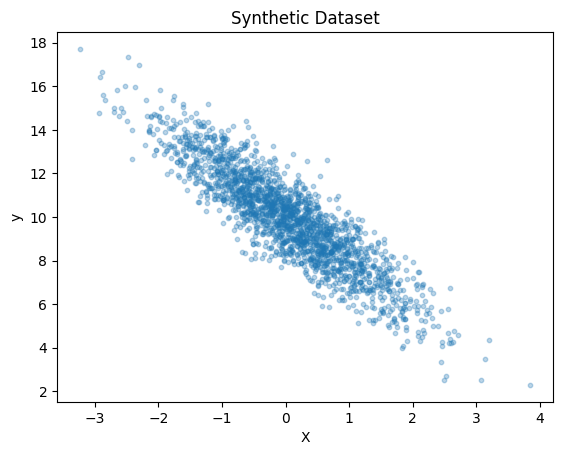

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate Dataset
np.random.seed(42)
N = 2000
X = np.random.randn(N)
y = 10 - 2 * X + np.random.randn(N)

plt.scatter(X, y, alpha=0.3, s=10)
plt.title("Synthetic Dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [14]:
# Step 2: Mini-Batch Gradient Descent
learning_rate = 0.01
epochs = 100
batch_size = 64

m = np.random.randn()
c = np.random.randn()
cost_history = []

for epoch in range(epochs):
    # Shuffle data at the start of each epoch
    indices = np.random.permutation(N)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    # Process mini-batches
    for start in range(0, N, batch_size):
        X_batch = X_shuffled[start:start + batch_size]
        y_batch = y_shuffled[start:start + batch_size]
        n_b = len(X_batch)

        y_pred = m * X_batch + c
        error = y_pred - y_batch

        dm = (2 / n_b) * np.dot(error, X_batch)
        dc = (2 / n_b) * np.sum(error)

        m -= learning_rate * dm
        c -= learning_rate * dc

    # Compute full-dataset MSE after each epoch
    cost = np.mean((m * X + c - y) ** 2)
    cost_history.append(cost)

print(f"Learned: m = {m:.4f}, c = {c:.4f}")
print(f"True:    m = -2.0000, c = 10.0000")

Learned: m = -2.0143, c = 10.0040
True:    m = -2.0000, c = 10.0000


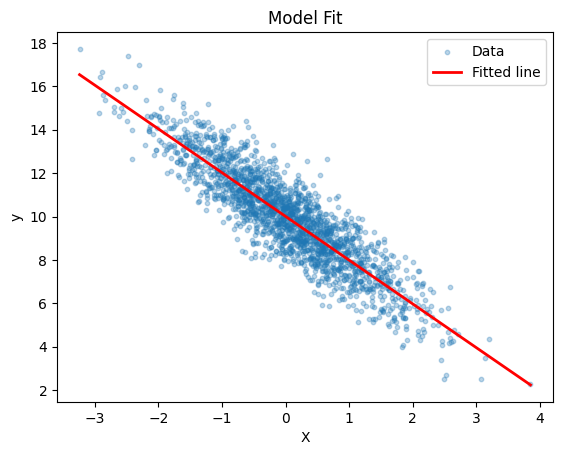

In [15]:
# Step 3a: Plot best-fit line
plt.scatter(X, y, alpha=0.3, s=10, label="Data")
X_line = np.linspace(X.min(), X.max(), 100)
plt.plot(X_line, m * X_line + c, color="red", linewidth=2, label="Fitted line")
plt.title("Model Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

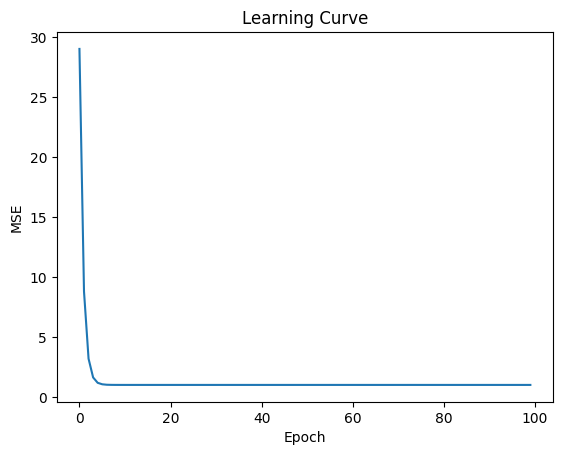

In [16]:
# Step 3b: Plot learning curve
plt.plot(cost_history)
plt.title("Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

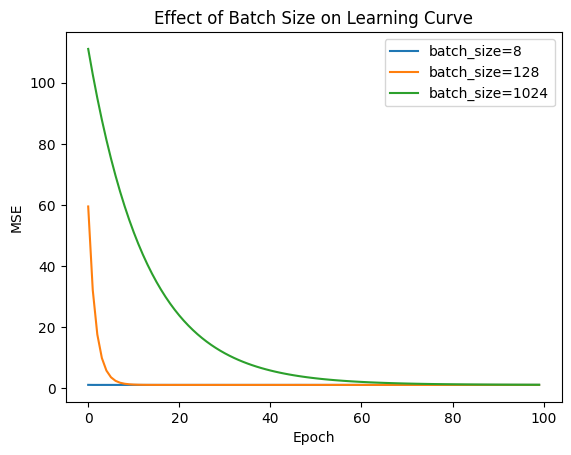

In [17]:
batch_sizes = [8, 128, 1024]

for bs in batch_sizes:
    m_b, c_b = np.random.randn(), np.random.randn()
    history = []

    for epoch in range(epochs):
        indices = np.random.permutation(N)
        X_s, y_s = X[indices], y[indices]

        for start in range(0, N, bs):
            X_b, y_b = X_s[start:start+bs], y_s[start:start+bs]
            err = m_b * X_b + c_b - y_b
            m_b -= learning_rate * (2/len(X_b)) * np.dot(err, X_b)
            c_b -= learning_rate * (2/len(X_b)) * np.sum(err)

        history.append(np.mean((m_b * X + c_b - y) ** 2))

    plt.plot(history, label=f"batch_size={bs}")

plt.title("Effect of Batch Size on Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()